# 02 - Exploratory Data Analysis

Basic exploration of the generated transaction data before feature engineering: class imbalance, amount distributions, time-of-day/velocity patterns, and how fraud scenarios differ from legitimate traffic.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.use('Agg')
%matplotlib inline

txns = pd.read_csv('data/processed/transactions.csv')
txns['timestamp'] = pd.to_datetime(txns['timestamp'], format='mixed')
scenario_labels = pd.read_csv('data/processed/transactions_scenario_labels.csv')
txns = txns.merge(scenario_labels, on='transaction_id')
txns.shape

(97424, 17)

## Class imbalance

This is why accuracy is a bad metric here -- see `evaluation/metrics.py`.

In [2]:
fraud_rate = txns.label.mean()
print(f'Fraud rate: {fraud_rate*100:.2f}%  ({txns.label.sum():,} of {len(txns):,} transactions)')
print(f'A model predicting "never fraud" would score {(1-fraud_rate)*100:.1f}% accuracy while catching zero fraud.')

Fraud rate: 5.41%  (5,274 of 97,424 transactions)
A model predicting "never fraud" would score 94.6% accuracy while catching zero fraud.


## Amount distribution: fraud vs legit

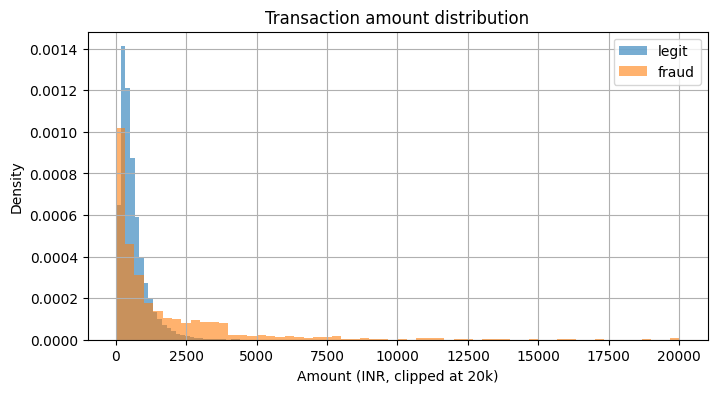

In [3]:
fig, ax = plt.subplots(figsize=(8,4))
txns[txns.label==0]['amount'].clip(upper=20000).hist(bins=60, alpha=0.6, label='legit', ax=ax, density=True)
txns[txns.label==1]['amount'].clip(upper=20000).hist(bins=60, alpha=0.6, label='fraud', ax=ax, density=True)
ax.set_xlabel('Amount (INR, clipped at 20k)'); ax.set_ylabel('Density'); ax.legend()
ax.set_title('Transaction amount distribution')
plt.show()

## Fraud rate by payment method

In [4]:
txns.groupby('payment_method')['label'].mean().sort_values(ascending=False)

payment_method
card          0.116581
upi           0.031790
netbanking    0.031653
wallet        0.030978
Name: label, dtype: float64

## Transactions per day over time (train/val/test boundary visible)

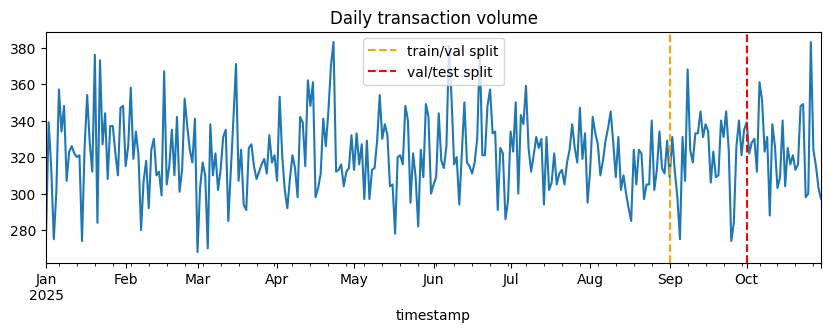

In [5]:
daily = txns.set_index('timestamp').resample('D').size()
fig, ax = plt.subplots(figsize=(10,3))
daily.plot(ax=ax)
ax.axvline(pd.Timestamp('2025-09-01'), color='orange', linestyle='--', label='train/val split')
ax.axvline(pd.Timestamp('2025-10-01'), color='red', linestyle='--', label='val/test split')
ax.set_title('Daily transaction volume'); ax.legend()
plt.show()

## Scenario breakdown

In [6]:
txns.groupby('scenario').agg(count=('transaction_id','count'), avg_amount=('amount','mean')).sort_values('count', ascending=False)

,count,avg_amount
scenario,,
legit,92150,627.948006
velocity_attack,1948,771.107582
card_testing,1581,660.477445
abuse_ring,1080,2168.944463
account_takeover,515,6153.518680
geo_anomaly,150,2341.360067
